## Financial Econometrics 2025 Midterm Project

### Present Value Approach
1. 使用指數：S&P 500 指數
2. 資料區間：1990年1月至2025年9月
3. 數據來源：https://shillerdata.com/  (Robert J. Shiller 網站數據)


1. 透過 Present Value Approach 預測股價報酬，回報預測結果
2. 畫出預期報酬與股利成長
3. 計算預測的表現 - R^2

In [ ]:
pip install filterpy

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 178.0/178.0 kB 5.3 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for filterpy: filename=filterpy-1.4.5-py3-none-any.whl size=110460 sha256=78b5d7fe0aaf14fb40d2307b49cb403e67f74e0738d86b86600b279e3029be60
  Stored in directory: /root/.cache/pip/wheels/77/bf/4c/b0c3f4798a0166668752312a67118b27a3cd341e13ac0ae6ee
Successfully built filterpy


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from filterpy.kalman import KalmanFilter
from scipy.optimize import minimize
from dataclasses import dataclass
import plotly.express as px
import warnings
warnings.filterwarnings("ignore", category=UserWarning)

一些小細節：
月頻率數據，透過Present Value方法結合Kalmon Fliter，然後使用MLE的方法來估算其中的參數

In Sample 1970-2000

Out Sample 2001-2025

先用In Sample 資料來訓練，找出一版參數（初始參數），然後接下來每年透過Out Sample數據去調整參數 (每年調整)

結果的部分 呈現
1. R^2 ：In Sample/ Out Sample，Return/Dividend4個數據
2. 每一年的參數調整 （從初始到2025） - 我這邊少初始數據
3. 繪製return/dividend 預測與實際數值



---



1. 資料前處理與分割，同時計算total log return, price-dividend ratio, aggregate log dividend growth rate

In [ ]:
raw = pd.read_excel("data.xlsx")
raw = raw.rename(columns={raw.columns[0]:"Date", raw.columns[1]:"Price", raw.columns[2]:"Dividend"})

def parse_year_month(x):
    s = str(x).strip()
    if "." in s:
        year, month = s.split(".")
        # 若月只有 1 位數（例：1980.1），補上 0 → 1980.10
        if len(month) == 1:
            month = month + "0"  # 假設資料中 .1 表示 10 月
        month = month.zfill(2)
    else:
        year, month = s[:4], s[4:]
    return int(year), int(month)

ym = raw["Date"].apply(parse_year_month)
raw["Year"]  = ym.apply(lambda x: x[0])
raw["Month"] = ym.apply(lambda x: x[1])
raw["Date"] = pd.to_datetime(dict(year=raw["Year"], month=raw["Month"], day=1)) + pd.offsets.MonthEnd(0)

raw = raw.sort_values(["Year","Month"]).reset_index(drop=True)
raw = raw[(raw["Year"]>=1970)].reset_index(drop=True)

# Total log return
raw["Price_lag"] = raw["Price"].shift(1)
raw["TotRet"] = (raw["Price"] + raw["Dividend"]) / raw["Price_lag"] - 1.0
raw["r_m"] = np.log1p(raw["TotRet"].fillna(0.0)) # 設定第一筆數據為0

# Price-dividends ratio & dividend growth
raw["pd_log"] = np.log(raw["Price"] / raw["Dividend"])
raw["Ad"] = np.log(raw["Dividend"] / raw["Dividend"].shift(1))
raw["Ad"] = np.log1p(raw["Ad"].fillna(0.0)) # 設定第一筆數據為0

df = raw.copy()
df = df.drop(columns=["Year", "Month", "Price_lag", "TotRet"])

# 切期，分成樣本內外
IS_END  = pd.Timestamp("2000-12-31")
OOS_BEG = pd.Timestamp("2001-01-01")
OOS_END = pd.Timestamp("2025-12-31")

df_is  = df[df["Date"]<=IS_END].copy()
df_oos = df[(df["Date"]>=OOS_BEG) & (df["Date"]<=OOS_END)].copy()

2. 設定函數來計算Present Value Approach

In [ ]:
# 模型參數設定：據平均本益比 pd_bar 與模型參數，計算 Campbell-Shiller 模型中的常數
def campbell_shiller_consts(pd_bar, delta1, delta0, gamma1, gamma0):
    """給 B1, B2, A, rho, kappa"""
    rho   = np.exp(pd_bar)/(1.0 + np.exp(pd_bar)) # 折現因子 rho，介於 (0,1)
    kappa = np.log1p(np.exp(pd_bar)) - rho*pd_bar
    B1 = 1.0/(1.0 - rho*delta1)
    B2 = 1.0/(1.0 - rho*gamma1)
    A  = kappa/(1.0 - rho) + (gamma0-delta0)/(1-rho)
    return A, B1, B2, rho, kappa


# 封裝模型參數
@dataclass
class Params:
    delta0: float; gamma0: float
    delta1: float; gamma1: float
    sigma_mu: float; sigma_g: float; sigma_v: float # 觀測誤差
    rho_mug: float;

# 設定參數上下限：將無界參數向量 theta 轉換為有意義的模型參數（有界）
def pack(theta):
    d0,g0,a1,a2,s1,s2,sv,c12 = theta
    delta1 = np.tanh(a1);  gamma1 = np.tanh(a2)
    sigma_mu = np.exp(s1); sigma_g = np.exp(s2); sigma_v = np.exp(sv)
    rho_mug  = np.tanh(c12)
    return Params(d0,g0,delta1,gamma1,sigma_mu,sigma_g,sigma_v,rho_mug)

# Kalman 濾波器與對數似然計算
def kf_loglik_and_filter(df_in, p: Params):
    """Kalman 濾波 + 對數似然（cash reinvested 規格，觀測是 pd_log - A）"""
    z = df_in["pd_log"].to_numpy() # 觀測變數：log(P/D)
    n = len(z)
    pd_bar = df_in["pd_log"].mean() # 平均本益比
    A, B1, B2, rho, kappa = campbell_shiller_consts(pd_bar, p.delta1, p.delta0, p.gamma1, p.gamma0)  # 觀測矩陣：z_t - A = H * x_t + v_t
    H = np.array([[-B1, B2]]) # 狀態轉移矩陣
    F = np.array([[p.delta1, 0.0],[0.0, p.gamma1]])
    Q = np.array([[p.sigma_mu**2, p.rho_mug*p.sigma_mu*p.sigma_g],
                  [p.rho_mug*p.sigma_mu*p.sigma_g, p.sigma_g**2]]) # 狀態誤差共變異數
    R = np.array([[p.sigma_v**2]]) # 觀測誤差共變異數

    kf = KalmanFilter(dim_x=2, dim_z=1) # 初始化 Kalman 濾波器（2 個狀態變數，1 個觀測變數）
    kf.F = F; kf.H = H; kf.Q = Q; kf.R = R
    kf.x = np.zeros((2,1)) # 初始狀態均值
    kf.P = np.diag([0.25,0.25])**2 # 初始狀態共變異數

    ll = 0.0 # 對數似然
    mu_hat = np.zeros(n); g_hat = np.zeros(n) # 儲存濾波後的 μ_t 與 g_t
    for t in range(n):
        kf.predict() # 預測步驟
        kf.update(np.array([[z[t]-A]])) # 更新步驟（觀測值減去常數 A）
        mu_hat[t] = p.delta0 + kf.x[0,0] # 加回 δ₀ 得到完整 μ_t
        g_hat[t]  = p.gamma0 + kf.x[1,0] # 加回 γ₀ 得到完整 g_t
        S = kf.S; innov = kf.y # 濾波器的創新與其共變異數
        ll += -0.5*(np.log(np.linalg.det(S)) + innov.T @ np.linalg.inv(S) @ innov + np.log(2*np.pi)) # 累積對數似然
    return float(-ll[0][0]), mu_hat, g_hat # 回傳負對數似然（供 MLE 最小化）


def estimate_mle(df_in, x0):
    """用 IS 資料 MLE 估參數"""
    # 起始值：均值與持續度用 AR(1)，噪音用樣本方差尺度

    def obj(theta):
        p = pack(theta)
        nll,_,_ = kf_loglik_and_filter(df_in, p)
        return nll
    res = minimize(obj, x0, method="L-BFGS-B")
    p_hat = pack(res.x)
    _, mu_hat, g_hat = kf_loglik_and_filter(df_in, p_hat)
    return p_hat, mu_hat, g_hat, res


def compute_R2(y, yhat):
    m = (~pd.isna(y)) & (~pd.isna(yhat))
    if m.sum()<3: return np.nan
    return 1.0 - np.var(y[m]-yhat[m], ddof=0)/np.var(y[m], ddof=0)


# 手動設定 In-Sample 初始值
d0 = 0.005; g0 = 0.01
phi_r = 0.9; phi_g = 0.9
s1 = np.log(0.01); s2 = np.log(0.01); sv = np.log(0.1)
x0_manual = np.array([
    d0, g0,
    np.arctanh(phi_r),
    np.arctanh(phi_g),
    s1, s2, sv, 0.0
])

3. 帶入實際數據計算In-Sample與Out-Sample結果

透過In-Sample跑出之各參數數值，當作Out-Sample的初始設定值，透過每年重新計算參數值的方式不斷循環

In [ ]:
# In-Sample 估計

# 使用樣本內資料 df_is 和手動設定的初始值 x0_manual 進行最大概似估計（MLE），回傳估計參數 p_is、濾波後的 μ_t（mu_is）與 g_t（g_is），以及優化結果 optres
p_is, mu_is, g_is, optres = estimate_mle(df_is, x0_manual)
df_is["mu_hat"] = mu_is # 將濾波後的 μ_t 存入樣本內資料中
df_is["g_hat"]  = g_is # 將濾波後的 g_t 存入樣本內資料中

# 計算樣本內預測能力（R²)
R2_is_ret = compute_R2(df_is["r_m"].shift(-1), df_is["mu_hat"]) # 用 μ_t 預測下一期報酬 r_{t+1}
R2_is_div = compute_R2(df_is["Ad"].shift(-1), df_is["g_hat"]) # 用 g_t 預測下一期股利成長 Δd_{t+1}
print(f"[IN] R^2 Return={R2_is_ret:.4f}  Dividend={R2_is_div:.4f}")

# Out-of-Sample 每年重估
# 建構儲存每年估計的參數、μ_t、g_t
rows = []
pred_r = [] ; pred_d = []
x0_oos = optres.x  # 使用 In-Sample 結果作為 OOS 起始值

for Y in range(2001, 2026):
    end = pd.Timestamp(f"{Y-1}-12-31")
    df_train = df[df["Date"]<=end]
    if len(df_train)<60:
        continue
    # 用訓練資料與前一年估計結果作為初始值進行 MLE
    p_y, mu_y, g_y, optres_y = estimate_mle(df_train, x0_oos)
    x0_oos = optres_y.x  # 更新起始值為本年估計結果

    # 儲存當年估計的參數
    rows.append({"year":Y,
                 "delta0":p_y.delta0, "gamma0":p_y.gamma0,
                 "delta1":p_y.delta1, "gamma1":p_y.gamma1,
                 "sigma_mu":p_y.sigma_mu, "sigma_g":p_y.sigma_g,
                 "sigma_v":p_y.sigma_v, "rho_mug":p_y.rho_mug})

    df_this = df[(df["Date"]>=pd.Timestamp(f"{Y}-01-01")) &
                 (df["Date"]<=pd.Timestamp(f"{Y}-12-31"))].copy()
    if len(df_this)==0:
        continue
    # 用訓練資料 + 當年度資料進行濾波，取得 μ_t 與 g_t
    _, mu_now, g_now = kf_loglik_and_filter(pd.concat([df_train, df_this]), p_y)
    mu_now  = mu_now[-len(df_this):]
    g_now   = g_now[-len(df_this):]
    df_this["mu_hat"] = mu_now
    df_this["g_hat"]  = g_now
    pred_r.append(df_this[["Date","mu_hat"]])
    pred_d.append(df_this[["Date","g_hat"]])

param_oos = pd.DataFrame(rows).sort_values("year")
pred_r = pd.concat(pred_r).merge(df[["Date","r_m"]], on="Date", how="left")
pred_d = pd.concat(pred_d).merge(df[["Date","Ad"]], on="Date", how="left")

R2_oos_ret = compute_R2(pred_r["r_m"].shift(-1), pred_r["mu_hat"])
R2_oos_div = compute_R2(pred_d["Ad"].shift(-1), pred_d["g_hat"])
print(f"[OOS 2001–2025] R^2 Return={R2_oos_ret:.4f}  Dividend={R2_oos_div:.4f}")

[IN] R^2 Return=0.0763  Dividend=-3.6443
[OOS 2001–2025] R^2 Return=0.0217  Dividend=0.0171


4. 視覺化與呈現整體結果

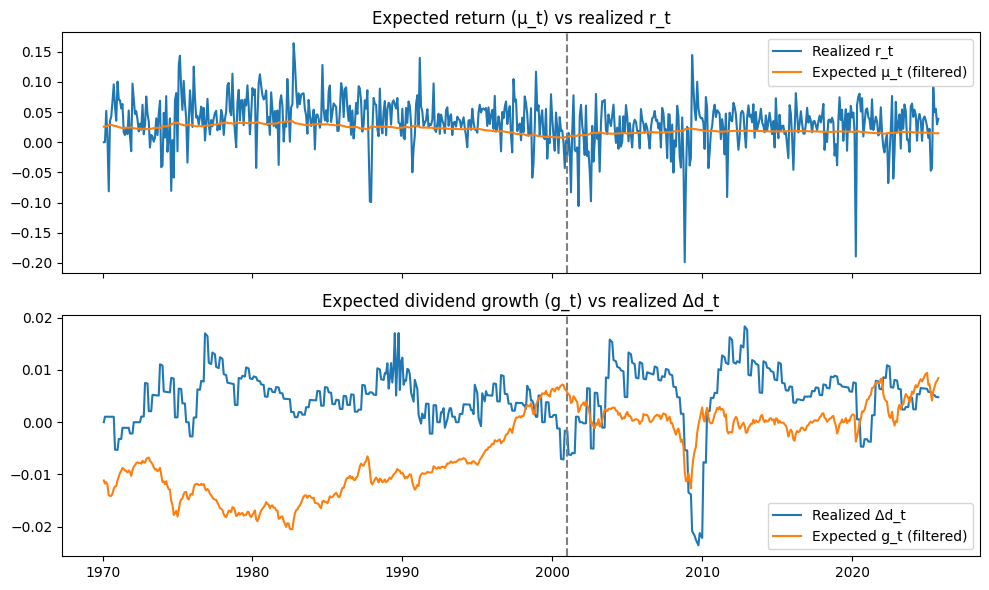


[In-sample R^2]
{'Return': 0.0763, 'Dividend': -3.6443}

[Out-of-sample R^2 2001–2025]
{'Return': 0.0217, 'Dividend': 0.0171}

[Yearly parameter re-estimation (OOS)]
 year  delta0  gamma0  delta1  gamma1  sigma_mu  sigma_g  sigma_v  rho_mug
 2001 -0.0364  0.0511  0.9993  0.9993    0.0023   0.0023      0.0   0.8791
 2002 -0.0178  0.0329  0.9991  0.9991    0.0024   0.0024      0.0   0.8866
 2003  0.0119  0.0027  0.9976  0.9976    0.0024   0.0025      0.0   0.8799
 2004  0.0070  0.0078  0.9982  0.9982    0.0024   0.0024      0.0   0.8840
 2005  0.0081  0.0066  0.9981  0.9981    0.0024   0.0024      0.0   0.8872
 2006  0.0131  0.0021  0.9975  0.9975    0.0023   0.0024      0.0   0.8882
 2007  0.0132  0.0020  0.9975  0.9975    0.0023   0.0024      0.0   0.8912
 2008  0.0154  0.0003  0.9971  0.9971    0.0024   0.0025      0.0   0.8972
 2009  0.0213 -0.0056  0.9958  0.9958    0.0024   0.0026      0.0   0.8876
 2010  0.0178 -0.0022  0.9961  0.9961    0.0024   0.0026      0.0   0.8844
 2011  0

In [ ]:
fig, ax = plt.subplots(2,1, figsize=(10,6), sharex=True)

# 預測與實際報酬變化
ax[0].plot(df["Date"], df["r_m"], label="Realized r_t")
ax[0].plot(pd.concat([df_is[["Date","mu_hat"]], pred_r.rename(columns={"mu_hat":"mu_hat"})])["Date"],
           pd.concat([df_is["mu_hat"], pred_r["mu_hat"]]), label="Expected μ_t (filtered)")
ax[0].set_title("Expected return (μ_t) vs realized r_t")
ax[0].legend()
ax[0].axvline(pd.Timestamp("2001-01-01"), color='gray', linestyle='--', label='Start of OOS')

# 預測與實際股利變化
ax[1].plot(df["Date"], df["Ad"], label="Realized Δd_t")
ax[1].plot(pd.concat([df_is[["Date","g_hat"]], pred_d.rename(columns={"g_hat":"g_hat"})])["Date"],
           pd.concat([df_is["g_hat"], pred_d["g_hat"]]), label="Expected g_t (filtered)")
ax[1].set_title("Expected dividend growth (g_t) vs realized Δd_t")
ax[1].legend()
ax[1].axvline(pd.Timestamp("2001-01-01"), color='gray', linestyle='--', label='Start of OOS')
plt.tight_layout()
plt.show()

# ---------- 輸出摘要 ----------
print("\n[In-sample R^2]")
print({"Return": round(R2_is_ret,4), "Dividend": round(R2_is_div,4)})
print("\n[Out-of-sample R^2 2001–2025]")
print({"Return": round(R2_oos_ret,4), "Dividend": round(R2_oos_div,4)})
print("\n[Yearly parameter re-estimation (OOS)]")
print(param_oos.round(4).to_string(index=False))

In [ ]:
pred_r

,Date,mu_hat,r_m
0,2001-01-31,0.009348,0.015559
1,2001-02-28,0.009604,-0.010394
2,2001-03-31,0.011008,-0.082941
3,2001-04-30,0.010865,0.016614
4,2001-05-31,0.009752,0.077837
...,...,...,...
292,2025-05-31,0.013149,0.092160
293,2025-06-30,0.012893,0.049746
294,2025-07-31,0.012584,0.055524
295,2025-08-31,0.012478,0.029815


#### 將 In-Sample, Out-Sample 分開繪製

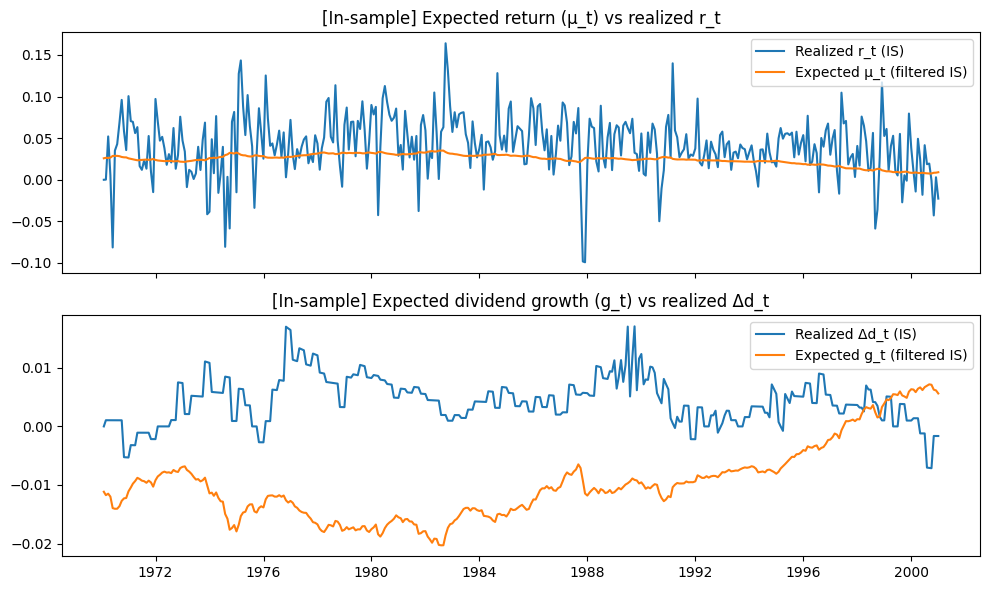

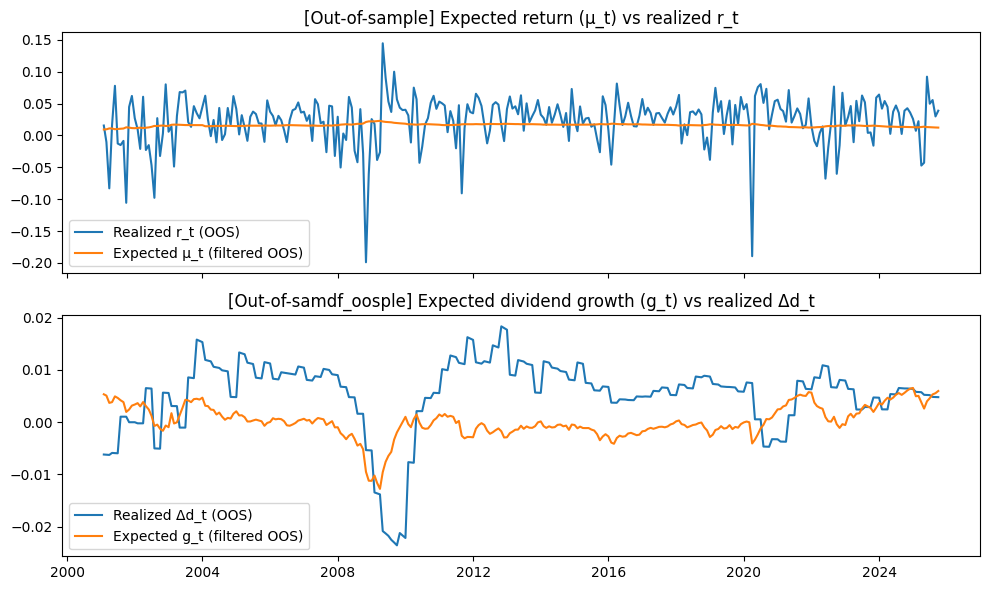


[In-sample R^2]
{'Return': 0.0767, 'Dividend': -3.598}

[Out-of-sample R^2 2001–2025]
{'Return': 0.0196, 'Dividend': 0.0555}

[Yearly parameter re-estimation (OOS)]
 year  delta0  gamma0  delta1  gamma1  sigma_mu  sigma_g  sigma_v  rho_mug
 2001 -0.0447  0.0593  0.9994  0.9994    0.0023   0.0023      0.0   0.8725
 2002 -0.0251  0.0397  0.9993  0.9993    0.0023   0.0024      0.0   0.8795
 2003  0.0114  0.0023  0.9976  0.9976    0.0024   0.0026      0.0   0.8893
 2004  0.0065  0.0072  0.9982  0.9982    0.0024   0.0025      0.0   0.8909
 2005  0.0071  0.0066  0.9982  0.9982    0.0024   0.0025      0.0   0.8938
 2006  0.0123  0.0017  0.9975  0.9975    0.0024   0.0025      0.0   0.8967
 2007  0.0125  0.0015  0.9975  0.9975    0.0024   0.0025      0.0   0.8995
 2008  0.0145 -0.0005  0.9971  0.9971    0.0024   0.0025      0.0   0.8993
 2009  0.0205 -0.0064  0.9958  0.9958    0.0024   0.0026      0.0   0.8892
 2010  0.0172 -0.0031  0.9959  0.9959    0.0025   0.0026      0.0   0.8862
 2011  0.

In [ ]:
# In-Sample
fig_is, ax_is = plt.subplots(2, 1, figsize=(10, 6), sharex=True)

# 報酬
ax_is[0].plot(df_is["Date"], df_is["r_m"], label="Realized r_t (IS)")
ax_is[0].plot(df_is["Date"], df_is["mu_hat"], label="Expected μ_t (filtered IS)")
ax_is[0].set_title("[In-sample] Expected return (μ_t) vs realized r_t")
ax_is[0].legend()

# 股利
ax_is[1].plot(df_is["Date"], df_is["Ad"], label="Realized Δd_t (IS)")
ax_is[1].plot(df_is["Date"], df_is["g_hat"], label="Expected g_t (filtered IS)")
ax_is[1].set_title("[In-sample] Expected dividend growth (g_t) vs realized Δd_t")
ax_is[1].legend()

plt.tight_layout()
plt.show()
print('')
# Out-of-Sample
fig_oos, ax_oos = plt.subplots(2, 1, figsize=(10, 6), sharex=True)
df_oos = df[(df["Date"]>=OOS_BEG) & (df["Date"]<=OOS_END)].copy()

# 報酬
ax_oos[0].plot(df_oos["Date"], df_oos["r_m"], label="Realized r_t (OOS)")
ax_oos[0].plot(df_oos["Date"], pred_r["mu_hat"], label="Expected μ_t (filtered OOS)")
ax_oos[0].set_title("[Out-of-sample] Expected return (μ_t) vs realized r_t")
ax_oos[0].legend()

# 股利
ax_oos[1].plot(df_oos["Date"], df_oos["Ad"], label="Realized Δd_t (OOS)")
ax_oos[1].plot(df_oos["Date"], pred_d["g_hat"], label="Expected g_t (filtered OOS)")
ax_oos[1].set_title("[Out-of-samdf_oosple] Expected dividend growth (g_t) vs realized Δd_t")
ax_oos[1].legend()

plt.tight_layout()
plt.show()

# ---------- 輸出摘要 ----------
print("\n[In-sample R^2]")
print({"Return": round(R2_is_ret,4), "Dividend": round(R2_is_div,4)})
print("\n[Out-of-sample R^2 2001–2025]")
print({"Return": round(R2_oos_ret,4), "Dividend": round(R2_oos_div,4)})
print("\n[Yearly parameter re-estimation (OOS)]")
print(param_oos.round(4).to_string(index=False))

### Bonus

#### 1. Compute the performance of asset allocation based on the expected return forecast. The allocation weight to the stock index could be any simple function of the expected return forecast. Compare the performance with the trailing mean forecast or the buy-and-hold strategy.

投資組合由 S&P 500 與無風險的 3 個月到期 T-Bill 組成，投資權重如下：

- **S&P 500**：  
  $$ w_t = 1(\mu_{t+1|t} > rf_t) $$

- **T-Bill**：  
  $$ 1 - w_t $$

最終組合的報酬為：

$$ R_{t+1} = w_t \cdot R_{t+1} + (1 - w_t) \cdot rf_{t+1} $$



In [ ]:
# 讀取 T-Bill 資料
tbill = pd.read_csv("TBill.csv")

# 重新命名欄位
tbill = tbill.rename(columns={tbill.columns[0]: "Date", tbill.columns[1]: "TB3MS"})

# 將日期轉換為 datetime 格式，並設為月末
tbill["Date"] = pd.to_datetime(tbill["Date"]) + pd.offsets.MonthEnd(0)

# 將年化利率轉換為月報酬率（假設 TB3MS 是年化百分比）
tbill["rf_monthly"] = tbill["TB3MS"] / 100 / 12

# 合併 pred_r 與 T-Bill 資料
merged = pd.merge(pred_r, tbill[["Date", "rf_monthly"]], on="Date", how="left")

# 計算 w_t 根據 mu_hat(t+1) > rf_monthly(t)
merged['mu_hat_next'] = merged['mu_hat'].shift(-1)
merged['w_t'] = (merged['mu_hat_next'] > merged['rf_monthly']).astype(float)

# 使用 w_t 與 t+1 的報酬率計算投資組合報酬率
merged['r_m_next'] = merged['r_m'].shift(-1)
merged['rf_next'] = merged['rf_monthly'].shift(-1)
merged['portfolio_return'] = merged['w_t'] * merged['r_m_next'] + (1 - merged['w_t']) * merged['rf_next']

# 計算累積報酬率
merged['cumulative_return'] = (1 + merged['portfolio_return']).cumprod() - 1

merged.to_csv("merged_portfolio.csv", index=False)
merged

,Date,mu_hat,r_m,rf_monthly,mu_hat_next,w_t,r_m_next,rf_next,portfolio_return,cumulative_return
0,2001-01-31,0.009348,0.015559,0.004292,0.009604,1.0,-0.010394,0.004067,-0.010394,-0.010394
1,2001-02-28,0.009604,-0.010394,0.004067,0.011008,1.0,-0.082941,0.003683,-0.082941,-0.092472
2,2001-03-31,0.011008,-0.082941,0.003683,0.010865,1.0,0.016614,0.003225,0.016614,-0.077394
3,2001-04-30,0.010865,0.016614,0.003225,0.009752,1.0,0.077837,0.003017,0.077837,-0.005581
4,2001-05-31,0.009752,0.077837,0.003017,0.010053,1.0,-0.012651,0.002908,-0.012651,-0.018161
...,...,...,...,...,...,...,...,...,...,...
292,2025-05-31,0.013149,0.092160,0.003542,0.012893,1.0,0.049746,0.003525,0.049746,702.029606
293,2025-06-30,0.012893,0.049746,0.003525,0.012584,1.0,0.055524,0.003542,0.055524,741.064287
294,2025-07-31,0.012584,0.055524,0.003542,0.012478,1.0,0.029815,0.003433,0.029815,763.188702
295,2025-08-31,0.012478,0.029815,0.003433,0.012299,1.0,0.038799,0.003267,0.038799,792.838556


Performance Comparison:
Present Value: {'Mean Return (%)': np.float64(2.36), 'Std Dev (%)': 3.82, 'Sharpe Ratio': np.float64(0.5777), 'Max Drawdown (%)': -30.41}
Trailing Mean: {'Mean Return (%)': np.float64(2.22), 'Std Dev (%)': 3.36, 'Sharpe Ratio': np.float64(0.6161), 'Max Drawdown (%)': -24.2}
Buy & Hold: {'Mean Return (%)': np.float64(2.35), 'Std Dev (%)': 3.81, 'Sharpe Ratio': np.float64(0.5783), 'Max Drawdown (%)': -30.41}


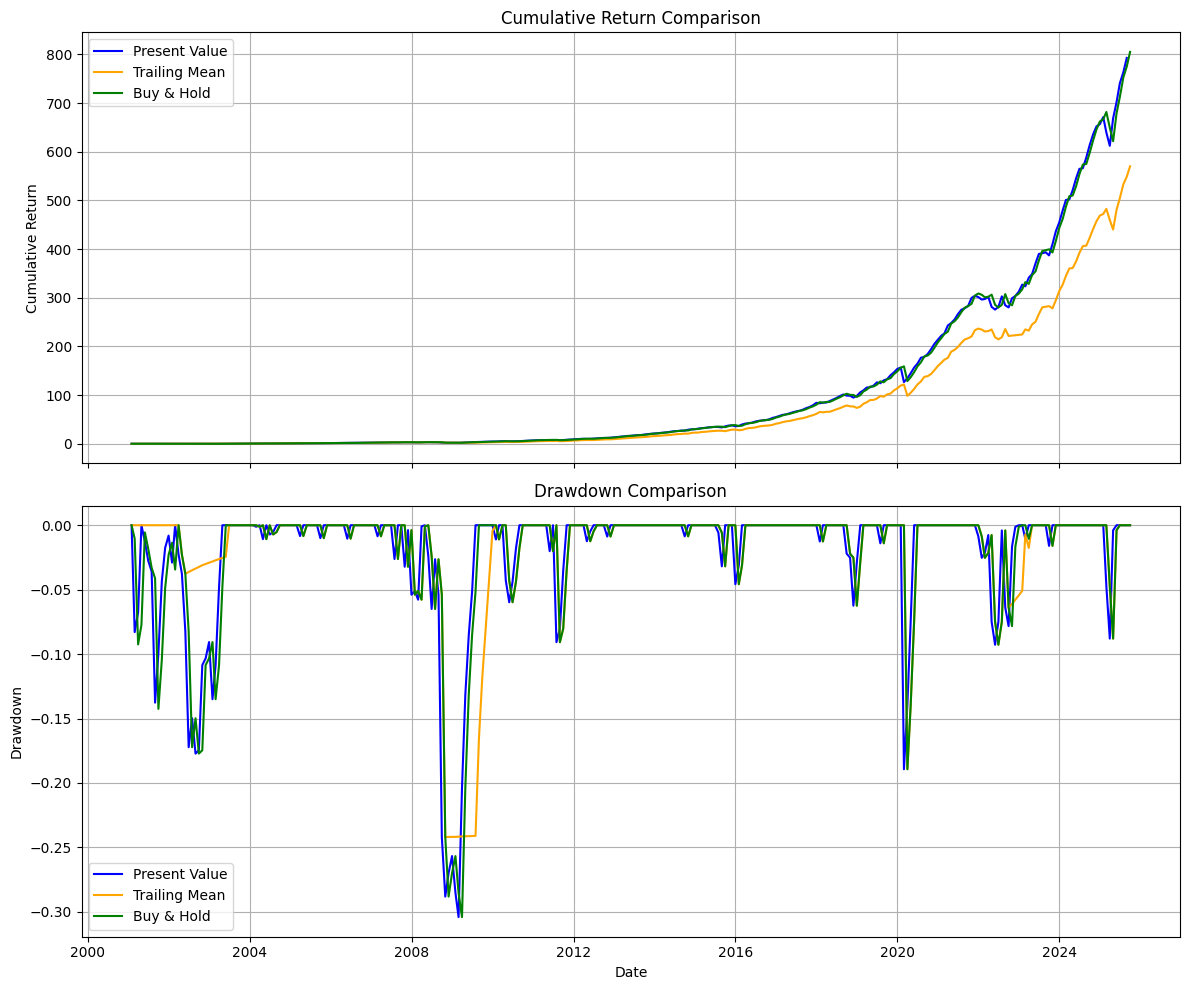

In [ ]:
# Buy-and-hold 策略
merged['return_bh'] = merged['r_m']
merged['cumulative_bh'] = (1 + merged['return_bh']).cumprod() - 1

# Trailing mean 策略
merged['mu_tm'] = merged['r_m'].rolling(window=12).mean().shift(1)
merged['w_tm'] = (merged['mu_tm'] > merged['rf_monthly']).astype(float)
merged['return_tm'] = merged['w_tm'] * merged['r_m'] + (1 - merged['w_tm']) * merged['rf_monthly']
merged['cumulative_tm'] = (1 + merged['return_tm'].fillna(0)).cumprod() - 1

def max_drawdown(cumulative):
    asset_value = cumulative + 1  # 將報酬率轉為資產值
    peak = asset_value.cummax()
    drawdown = (asset_value - peak) / peak
    return drawdown.min()

# 計算績效指標函數
def performance_metrics(returns, rf, cumulative):
    excess = returns - rf
    return {
        "Mean Return (%)": round(returns.mean() * 100, 2),
        "Std Dev (%)": round(returns.std(ddof=0) * 100, 2),
        "Sharpe Ratio": round(excess.mean() / excess.std(ddof=0), 4),
        "Max Drawdown (%)": round(max_drawdown(cumulative) * 100, 2)
    }

# 計算三種策略績效
perf_pv = performance_metrics(merged['portfolio_return'], merged['rf_monthly'], merged['cumulative_return'])
perf_tm = performance_metrics(merged['return_tm'], merged['rf_monthly'], merged['cumulative_tm'])
perf_bh = performance_metrics(merged['return_bh'], merged['rf_monthly'], merged['cumulative_bh'])

# 顯示績效表格
print("Performance Comparison:")
print("Present Value:", perf_pv)
print("Trailing Mean:", perf_tm)
print("Buy & Hold:", perf_bh)

# 繪製累積報酬率與最大跌幅圖
fig, ax = plt.subplots(2, 1, figsize=(12, 10), sharex=True)

# 累積報酬率
ax[0].plot(merged['Date'], merged['cumulative_return'], label='Present Value', color='blue')
ax[0].plot(merged['Date'], merged['cumulative_tm'], label='Trailing Mean', color='orange')
ax[0].plot(merged['Date'], merged['cumulative_bh'], label='Buy & Hold', color='green')
ax[0].set_title('Cumulative Return Comparison')
ax[0].set_ylabel('Cumulative Return')
ax[0].legend()
ax[0].grid(True)


def drawdown_series(cumulative):
    asset_value = cumulative + 1  # 將報酬率轉為資產值
    peak = asset_value.cummax()
    drawdown = (asset_value - peak) / peak
    return drawdown.fillna(0)

ax[1].plot(merged['Date'], drawdown_series(merged['cumulative_return']), label='Present Value', color='blue')
ax[1].plot(merged['Date'], drawdown_series(merged['cumulative_tm']), label='Trailing Mean', color='orange')
ax[1].plot(merged['Date'], drawdown_series(merged['cumulative_bh']), label='Buy & Hold', color='green')
ax[1].set_title('Drawdown Comparison')
ax[1].set_xlabel('Date')
ax[1].set_ylabel('Drawdown')
ax[1].legend()
ax[1].grid(True)

fig.tight_layout()



*   現值策略在報酬率、風險（標準差）、以及風險調整報酬（夏普比率）方面都表現最佳，代表它在整體報酬與效率上最具優勢。
*   移動平均策略雖然報酬較低，但最大跌幅最小，表示它在控制損失方面表現較穩健，適合保守型投資者。
*   買進持有策略的報酬與風險介於兩者之間，但最大跌幅最嚴重，代表在市場下跌時承受的損失可能最大。



#### 2. Examine the sensitivity of the estimated parameters to various initial values.

我們的運作架構是先設定一組參數，透過In-Sample數據找出最佳參數解，接著將此最佳解當作Out-Sample的初始參數值，並透過每一年新增之數據去重新調整參數值。

以下敏感度分析是針對最初我們手動設定之參數，觀察不同的參數設定是否得到一樣的穩定結果

In [ ]:

def safe_estimate_mle(df, x0):
    try:
        # 限制指數參數範圍避免 overflow
        x0 = np.clip(x0, -10, 10)
        p_hat, mu_hat, g_hat, res = estimate_mle(df, x0)
        return {
            "delta0": round(p_hat.delta0, 4),
            "gamma0": round(p_hat.gamma0, 4),
            "delta1": round(p_hat.delta1, 4),
            "gamma1": round(p_hat.gamma1, 4),
            "sigma_mu": round(p_hat.sigma_mu, 4),
            "sigma_g": round(p_hat.sigma_g, 4),
            "sigma_v": round(p_hat.sigma_v, 4),
            "rho_mug": round(p_hat.rho_mug, 4),
            "NegLogLik": round(res.fun, 4)
        }
    except Exception as e:
        return {
            "delta0": np.nan,
            "gamma0": np.nan,
            "delta1": np.nan,
            "gamma1": np.nan,
            "sigma_mu": np.nan,
            "sigma_g": np.nan,
            "sigma_v": np.nan,
            "rho_mug": np.nan,
            "NegLogLik": np.nan,
            "Error": str(e)
        }

# 設定多組初始值進行敏感度分析
initial_sets = [
    np.array([0.005, 0.01, np.arctanh(0.9), np.arctanh(0.9), np.log(0.01), np.log(0.01), np.log(0.1), 0.0]), # 原始設定
    np.array([0.01, 0.02, np.arctanh(0.8), np.arctanh(0.8), np.log(0.02), np.log(0.02), np.log(0.2), 0.1]), # 偏高均值與噪音
    np.array([0.0, 0.0, np.arctanh(0.5), np.arctanh(0.5), np.log(0.005), np.log(0.005), np.log(0.05), -0.1]), # 零均值、低持續度、低噪音，測試模型在弱訊號下表現
    np.array([-0.005, -0.01, np.arctanh(0.95), np.arctanh(0.95), np.log(0.03), np.log(0.03), np.log(0.3), 0.2]), # 負均值、高持續度、高噪音，測試模型在極端假設下表現
    np.array([0.002, 0.002, np.arctanh(0.7), np.arctanh(0.7), np.log(0.015), np.log(0.015), np.log(0.15), 0.05]),  # 中間值
    np.array([0.02, 0.03, np.arctanh(0.99), np.arctanh(0.99), np.log(0.05), np.log(0.05), np.log(0.5), 0.3]),     # 非常高持續度與噪音
    np.array([0.002, 0.002, np.arctanh(0.7), np.arctanh(0.7), np.log(0.015), np.log(0.015), np.log(0.15), 0.05]),  # 中間值
    #np.array([-0.01, -0.02, np.arctanh(0.3), np.arctanh(0.3), np.log(0.001), np.log(0.001), np.log(0.01), -0.2]), # 非常弱訊號與負均值
    #np.random.normal(loc=0.0, scale=0.05, size=8),  # 隨機擾動初始值
    #np.random.normal(loc=0.01, scale=0.1, size=8)   # 更大範圍隨機擾動
]

# 儲存結果
sensitivity_results = []

# 使用 In-Sample 資料 df_is 進行敏感度分析
for i, x0 in enumerate(initial_sets):
    result = safe_estimate_mle(df_is, x0)
    result["Init_Set"] = i + 1
    sensitivity_results.append(result)

# 建立結果表格
columns = ["Init_Set", "delta0", "gamma0", "delta1", "gamma1", "sigma_mu", "sigma_g", "sigma_v", "rho_mug", "NegLogLik"]


# 顯示結果表格
df_sensitivity = pd.DataFrame(sensitivity_results, columns=columns)
print("\n[Sensitivity Analysis of Initial Values]")
print(df_sensitivity.to_string(index=False))


[Sensitivity Analysis of Initial Values]
 Init_Set  delta0  gamma0  delta1  gamma1  sigma_mu  sigma_g  sigma_v  rho_mug  NegLogLik
        1 -0.0446  0.0593  0.9994  0.9994    0.0023   0.0023      0.0   0.8725  -702.3735
        2 -0.0373  0.0668  0.9994  0.9994    0.0036   0.0036      0.0   0.9486  -702.3735
        3 -0.0516  0.0521  0.9994  0.9994    0.0018   0.0018      0.0   0.8008  -702.3735
        4 -0.0132 -0.0020  0.9931  0.9955    0.0059   0.0063      0.0   0.9846  -702.5574
        5 -0.0512  0.0547  0.9994  0.9994    0.0028   0.0028      0.0   0.9141  -702.3735
        6  0.0396  0.0099  0.9545  0.9421    0.0570   0.0673      0.0   0.9994  -706.6030
        7 -0.0512  0.0547  0.9994  0.9994    0.0028   0.0028      0.0   0.9141  -702.3735




*   delta1, gamma1 在所有初始值下都非常接近1，顯示參數對於初始值不敏感；delta0, gamm0 則有明顯變化
*   sigma_mu 和 sigma_g 在不同初始值下略有變化，但整體數值偏小，代表模型估計的訊號波動性低；sigma_v 幾乎為 0，可能代表該誤差項在模型中被壓制或不重要
*   rho_mug 在不同初始值下變化範圍為 0.80 ~ 0.98，顯示 μ 與 g 間的誤差項有高度相關性
*   NegLogLik 數值非常接近（約 -702.3735），表示不同初始值下模型都能收斂到類似的擬合結果



##### Out-Sample敏感度分析 (數據太大跑不動)

In [ ]:
# Out-of-Sample 敏感度分析

# 先取得 In-Sample 最終估計結果作為基準初始值，每年使用 In-Sample 結果作為初始值，觀察參數估計是否穩定
x0_base = optres.x  # optres 是你前面 In-Sample MLE 的結果

# 設定多組初始值：以 IS 結果為中心，做些微擾動
initial_sets = [
    x0_base,
    x0_base + np.array([0.001, 0.001, 0.1, 0.1, 0.1, 0.1, 0.1, 0.05]),
    x0_base - np.array([0.001, 0.001, 0.1, 0.1, 0.1, 0.1, 0.1, 0.05]),
    x0_base + np.random.normal(0, 0.05, size=8)  # 加入隨機微擾
]

sensitivity_oos = []

# 針對每一年重新更新之參數值去跑敏感度分析
for Y in range(2001, 2026):
    end = pd.Timestamp(f"{Y-1}-12-31")
    df_train = df[df["Date"] <= end]
    if len(df_train) < 60:
        continue

    for i, x0 in enumerate(initial_sets):
        p_y, _, _, res_y = estimate_mle(df_train, x0)
        sensitivity_oos.append({
            "Year": Y,
            "Init_Set": i + 1,
            "delta0": round(p_y.delta0, 4),
            "gamma0": round(p_y.gamma0, 4),
            "delta1": round(p_y.delta1, 4),
            "gamma1": round(p_y.gamma1, 4),
            "sigma_mu": round(p_y.sigma_mu, 4),
            "sigma_g": round(p_y.sigma_g, 4),
            "sigma_v": round(p_y.sigma_v, 4),
            "rho_mug": round(p_y.rho_mug, 4),
            "NegLogLik": round(res_y.fun, 4)
        })

# 顯示結果
df_sensitivity_oos = pd.DataFrame(sensitivity_oos)
print("\n[Out-of-Sample Sensitivity Analysis by Initial Value and Year]")
print(df_sensitivity_oos.to_string(index=False))

KeyboardInterrupt: 

#### 3. Compare the overall performance with simple linear regression, e.g.,
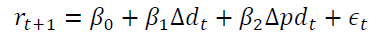

=== R² Comparison ===
[IN] Kalman Return R² = 0.0767
[IN] Linear Return R² = 0.0924
[IN] Kalman Dividend R² = -3.5980
[IN] Linear Dividend R² = 0.0999
[OOS] Kalman Return R² = 0.0196
[OOS] Linear Return R² = 0.0224
[OOS] Kalman Dividend R² = 0.0555
[OOS] Linear Dividend R² = 0.0611


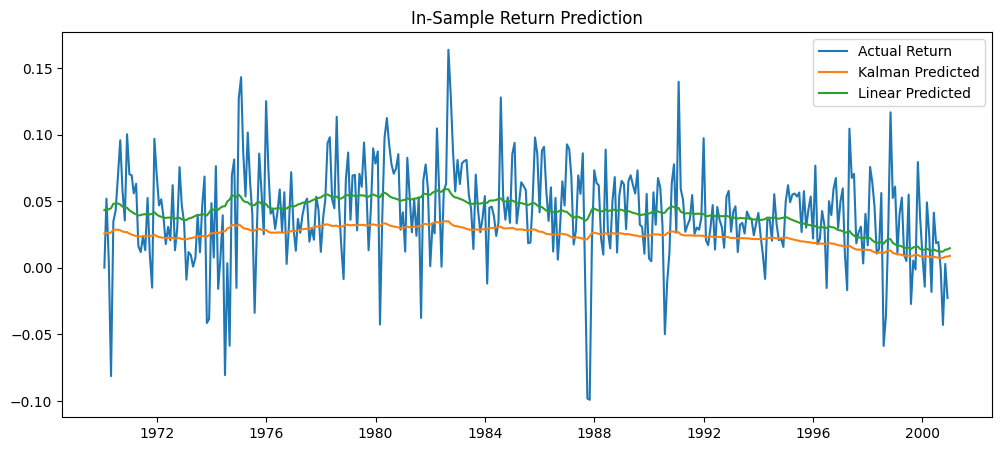

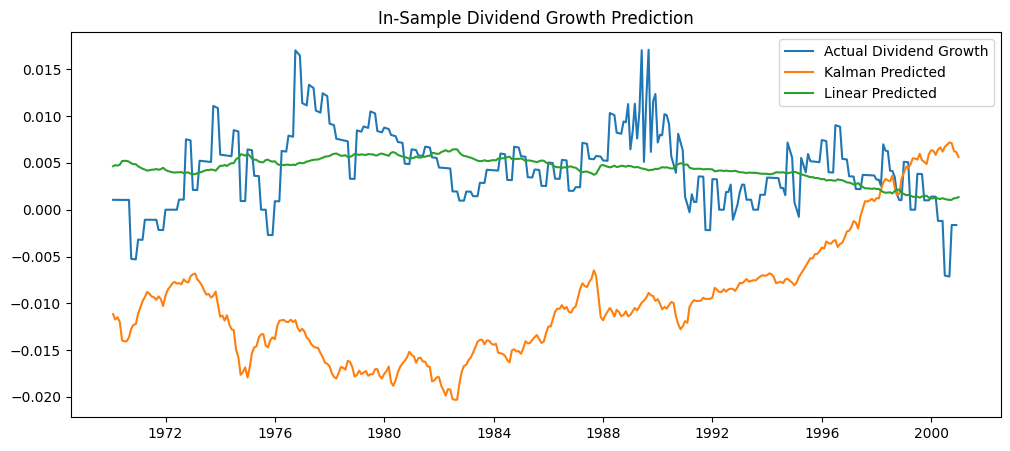

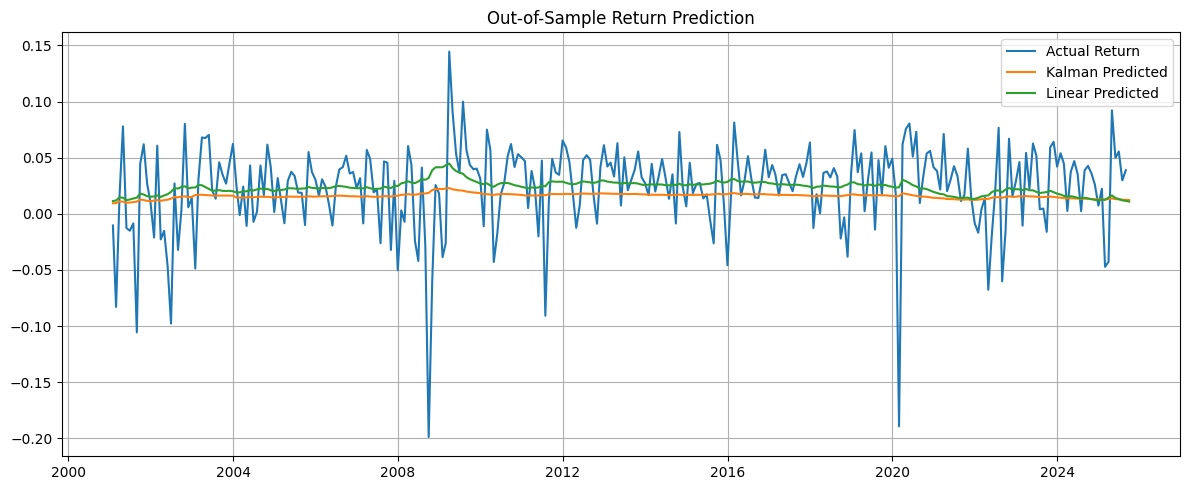

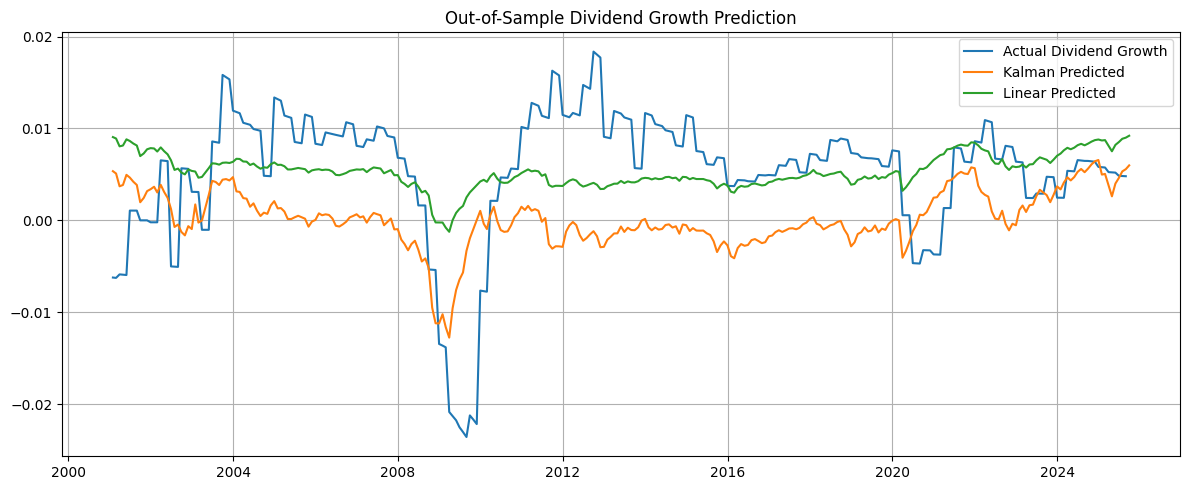

In [ ]:
from sklearn.linear_model import LinearRegression

df_oos = df_oos.merge(pred_r[["Date", "mu_hat"]], on="Date", how="left")
df_oos = df_oos.merge(pred_d[["Date", "g_hat"]], on="Date", how="left")

def compute_R2(y, yhat):
    m = (~pd.isna(y)) & (~pd.isna(yhat))
    if m.sum() < 3: return np.nan
    return 1.0 - np.var(y[m] - yhat[m], ddof=0) / np.var(y[m], ddof=0)

# 線性迴歸模型（樣本內）
lr_ret_is = LinearRegression().fit(df_is[["pd_log"]][:-1], df_is["r_m"].shift(-1)[:-1])
df_is["lr_ret_pred"] = lr_ret_is.predict(df_is[["pd_log"]])

lr_div_is = LinearRegression().fit(df_is[["pd_log"]][:-1], df_is["Ad"].shift(-1)[:-1])
df_is["lr_div_pred"] = lr_div_is.predict(df_is[["pd_log"]])

# 線性迴歸模型（樣本外）
lr_ret_oos = LinearRegression().fit(df_oos[["pd_log"]][:-1], df_oos["r_m"].shift(-1)[:-1])
df_oos["lr_ret_pred"] = lr_ret_oos.predict(df_oos[["pd_log"]])

lr_div_oos = LinearRegression().fit(df_oos[["pd_log"]][:-1], df_oos["Ad"].shift(-1)[:-1])
df_oos["lr_div_pred"] = lr_div_oos.predict(df_oos[["pd_log"]])

# R² 比較
print("=== R² Comparison ===")
print(f"[IN] Kalman Return R² = {compute_R2(df_is['r_m'].shift(-1), df_is['mu_hat']):.4f}")
print(f"[IN] Linear Return R² = {compute_R2(df_is['r_m'].shift(-1), df_is['lr_ret_pred']):.4f}")
print(f"[IN] Kalman Dividend R² = {compute_R2(df_is['Ad'].shift(-1), df_is['g_hat']):.4f}")
print(f"[IN] Linear Dividend R² = {compute_R2(df_is['Ad'].shift(-1), df_is['lr_div_pred']):.4f}")

print(f"[OOS] Kalman Return R² = {compute_R2(df_oos['r_m'].shift(-1), df_oos['mu_hat']):.4f}")
print(f"[OOS] Linear Return R² = {compute_R2(df_oos['r_m'].shift(-1), df_oos['lr_ret_pred']):.4f}")
print(f"[OOS] Kalman Dividend R² = {compute_R2(df_oos['Ad'].shift(-1), df_oos['g_hat']):.4f}")
print(f"[OOS] Linear Dividend R² = {compute_R2(df_oos['Ad'].shift(-1), df_oos['lr_div_pred']):.4f}")

# 畫圖比較（樣本內）
plt.figure(figsize=(12,5))
plt.plot(df_is["Date"], df_is["r_m"].shift(-1), label="Actual Return")
plt.plot(df_is["Date"], df_is["mu_hat"], label="Kalman Predicted")
plt.plot(df_is["Date"], df_is["lr_ret_pred"], label="Linear Predicted")
plt.title("In-Sample Return Prediction")
plt.legend()
plt.show()

plt.figure(figsize=(12,5))
plt.plot(df_is["Date"], df_is["Ad"].shift(-1), label="Actual Dividend Growth")
plt.plot(df_is["Date"], df_is["g_hat"], label="Kalman Predicted")
plt.plot(df_is["Date"], df_is["lr_div_pred"], label="Linear Predicted")
plt.title("In-Sample Dividend Growth Prediction")
plt.legend()
plt.show()

print(" ")

# 樣本外報酬預測比較
plt.figure(figsize=(12,5))
plt.plot(df_oos["Date"], df_oos["r_m"].shift(-1), label="Actual Return")
plt.plot(df_oos["Date"], df_oos["mu_hat"], label="Kalman Predicted")
plt.plot(df_oos["Date"], df_oos["lr_ret_pred"], label="Linear Predicted")
plt.title("Out-of-Sample Return Prediction")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# 樣本外股利成長預測比較
plt.figure(figsize=(12,5))
plt.plot(df_oos["Date"], df_oos["Ad"].shift(-1), label="Actual Dividend Growth")
plt.plot(df_oos["Date"], df_oos["g_hat"], label="Kalman Predicted")
plt.plot(df_oos["Date"], df_oos["lr_div_pred"], label="Linear Predicted")
plt.title("Out-of-Sample Dividend Growth Prediction")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


考慮要不要像是第一題一樣，繪製累積報酬與drawdown圖

#### 4. Estimate the alternative state space representation specified in Equations (4) to (6) in van Binbergen and Koijen (2010, “Predictive Regressions: A Present‐Value Approach”)

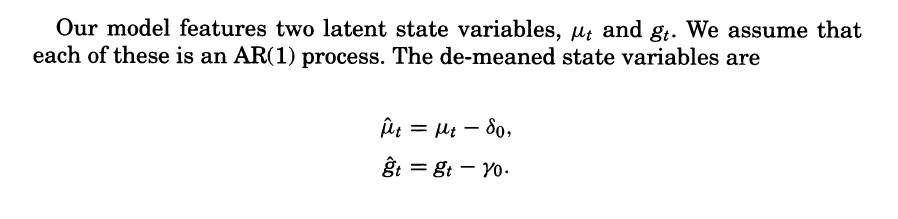
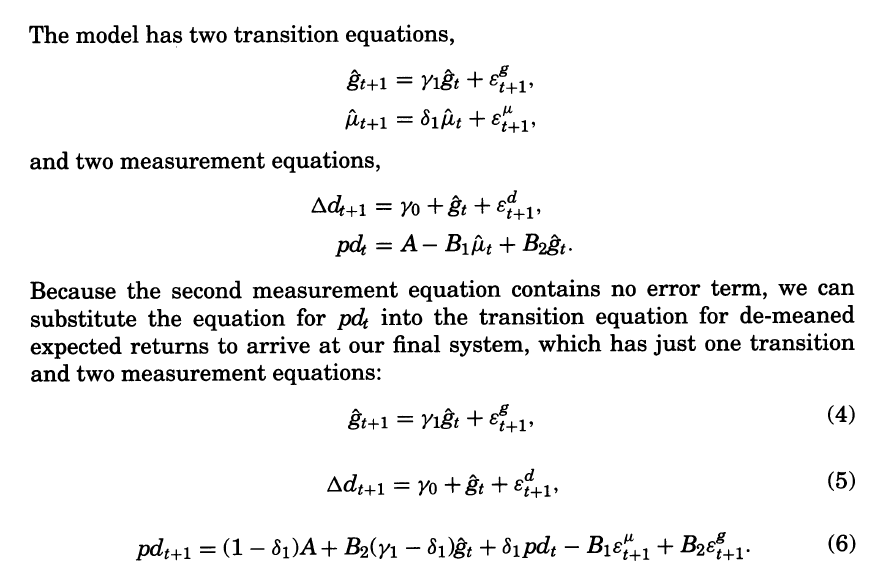

In [ ]:

# Define constants and parameter class
@dataclass
class CenteredParams:
    delta0: float; gamma0: float
    delta1: float; gamma1: float
    sigma_mu: float; sigma_g: float; sigma_v: float
    rho_mug: float

def centered_pack(theta):
    d0, g0, a1, a2, s1, s2, sv, c12 = theta
    delta1 = np.tanh(a1)
    gamma1 = np.tanh(a2)
    sigma_mu = np.exp(s1)
    sigma_g = np.exp(s2)
    sigma_v = np.exp(sv)
    rho_mug = np.tanh(c12)
    return CenteredParams(d0, g0, delta1, gamma1, sigma_mu, sigma_g, sigma_v, rho_mug)

def kf_centered_loglik_and_filter(df_in, p: CenteredParams):
    z = df_in["pd_log"].to_numpy()
    n = len(z)
    pd_bar = df_in["pd_log"].mean()
    A, B1, B2, rho, kappa = campbell_shiller_consts(pd_bar, p.delta1, p.delta0, p.gamma1, p.gamma0)

    H = np.array([[-B1, B2]])
    F = np.array([[p.delta1, 0.0], [0.0, p.gamma1]])
    Q = np.array([[p.sigma_mu**2, p.rho_mug * p.sigma_mu * p.sigma_g],
                  [p.rho_mug * p.sigma_mu * p.sigma_g, p.sigma_g**2]])
    R = np.array([[p.sigma_v**2]])

    kf = KalmanFilter(dim_x=2, dim_z=1)
    kf.F = F
    kf.H = H
    kf.Q = Q
    kf.R = R
    kf.x = np.zeros((2, 1))
    kf.P = np.diag([0.3, 0.3])**2

    ll = 0.0
    mu_hat = np.zeros(n)
    g_hat = np.zeros(n)

    for t in range(n):
        kf.predict()
        kf.update(np.array([[z[t] - A]]))
        mu_hat[t] = p.delta0 + kf.x[0, 0]
        g_hat[t] = p.gamma0 + kf.x[1, 0]
        S = kf.S
        innov = kf.y
        ll += -0.5 * (np.log(np.linalg.det(S)) + innov.T @ np.linalg.inv(S) @ innov + np.log(2 * np.pi))

    return float(-ll[0][0]), mu_hat, g_hat

def estimate_centered_mle(df_in, x0):
    def obj(theta):
        p = centered_pack(theta)
        nll, _, _ = kf_centered_loglik_and_filter(df_in, p)
        return nll

    res = minimize(obj, x0, method="L-BFGS-B")
    p_hat = centered_pack(res.x)
    _, mu_hat, g_hat = kf_centered_loglik_and_filter(df_in, p_hat)
    return p_hat, mu_hat, g_hat, res

# Run estimation on df_is
x0_centered = [0.005, 0.01, np.arctanh(0.9), np.arctanh(0.9), np.log(0.01), np.log(0.01), np.log(0.1), 0.0]
p_is, mu_is, g_is, optres = estimate_centered_mle(df_is, x0_centered)

print("[Centered Model] Estimated Parameters:")
print(p_is)


[Centered Model] Estimated Parameters:
CenteredParams(delta0=np.float64(-0.0446351659378885), gamma0=np.float64(0.05930000518104111), delta1=np.float64(0.9993797930933764), gamma1=np.float64(0.9993796901618245), sigma_mu=np.float64(0.0022774351633648086), sigma_g=np.float64(0.002278389174958515), sigma_v=np.float64(1.5400609481406575e-05), rho_mug=np.float64(0.8725469794541064))


In [ ]:

# In-Sample 估計
df_is["mu_hat"] = mu_is
df_is["g_hat"] = g_is

R2_is_ret = compute_R2(df_is["r_m"].shift(-1), df_is["mu_hat"])
R2_is_div = compute_R2(df_is["Ad"].shift(-1), df_is["g_hat"])

# Out-of-Sample 每年重估
rows = []
pred_r = []
pred_d = []
x0_oos = optres.x

for Y in range(2001, 2026):
    end = pd.Timestamp(f"{Y-1}-12-31")
    df_train = df[df["Date"] <= end]
    if len(df_train) < 60:
        continue

    # 重新估計參數（包含 delta0, gamma0）
    p_y, mu_y, g_y, optres_y = estimate_centered_mle(df_train, x0_oos)
    x0_oos = optres_y.x

    # 儲存參數
    rows.append({
        "year": Y,
        "delta0": p_y.delta0, "gamma0": p_y.gamma0,
        "delta1": p_y.delta1, "gamma1": p_y.gamma1,
        "sigma_mu": p_y.sigma_mu, "sigma_g": p_y.sigma_g,
        "sigma_v": p_y.sigma_v, "rho_mug": p_y.rho_mug
    })

    # 當年度資料
    df_this = df[(df["Date"] >= pd.Timestamp(f"{Y}-01-01")) & (df["Date"] <= pd.Timestamp(f"{Y}-12-31"))].copy()
    if len(df_this) == 0:
        continue

    # 濾波器預測（使用估計出的 delta0, gamma0）
    _, mu_now, g_now = kf_centered_loglik_and_filter(pd.concat([df_train, df_this]), p_y)
    mu_now = mu_now[-len(df_this):]
    g_now = g_now[-len(df_this):]
    df_this["mu_hat"] = mu_now
    df_this["g_hat"] = g_now
    pred_r.append(df_this[["Date", "mu_hat"]])
    pred_d.append(df_this[["Date", "g_hat"]])

# 合併預測結果與實際值
param_oos = pd.DataFrame(rows).sort_values("year")
pred_r = pd.concat(pred_r).merge(df[["Date", "r_m"]], on="Date", how="left")
pred_d = pd.concat(pred_d).merge(df[["Date", "Ad"]], on="Date", how="left")

# 計算樣本外 R²
R2_oos_ret = compute_R2(pred_r["r_m"].shift(-1), pred_r["mu_hat"])
R2_oos_div = compute_R2(pred_d["Ad"].shift(-1), pred_d["g_hat"])

# 顯示結果
print(f"[IN - Centered] R^2 Return = {R2_is_ret:.4f}  Dividend = {R2_is_div:.4f}")
print(f"[OOS 2001–2025 - Centered] R^2 Return = {R2_oos_ret:.4f}  Dividend = {R2_oos_div:.4f}")

[IN - Centered] R^2 Return = 0.0767  Dividend = -3.5980
[OOS 2001–2025 - Centered] R^2 Return = 0.0196  Dividend = 0.0555


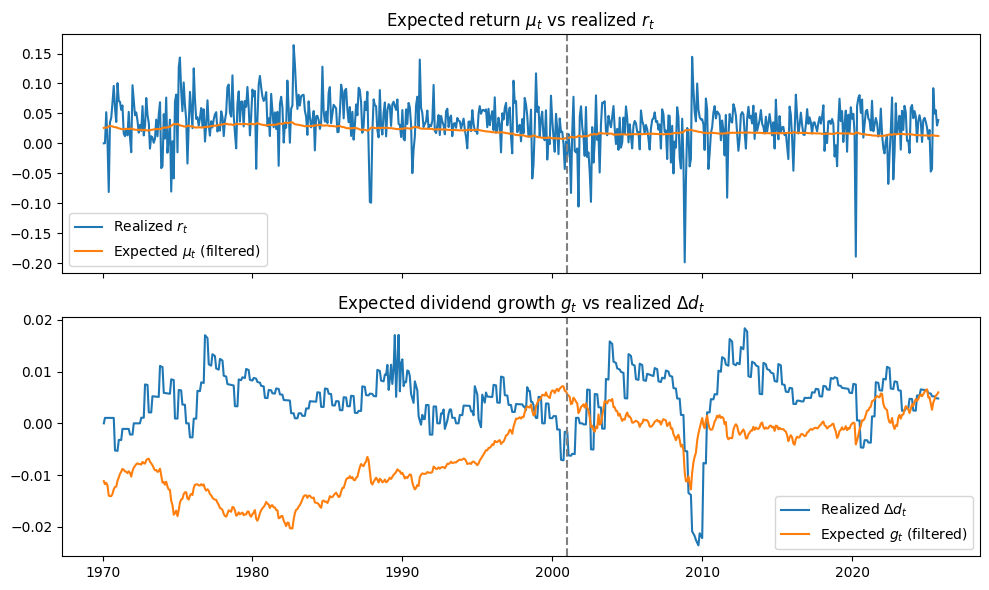


[In-sample R²]
{'Return': 0.0767, 'Dividend': -3.598}

[Out-of-sample R² 2001–2025]
{'Return': 0.0196, 'Dividend': 0.0555}

[Yearly parameter re-estimation (OOS)]
 year  delta0  gamma0  delta1  gamma1  sigma_mu  sigma_g  sigma_v  rho_mug
 2001 -0.0447  0.0593  0.9994  0.9994    0.0023   0.0023      0.0   0.8725
 2002 -0.0251  0.0397  0.9993  0.9993    0.0023   0.0024      0.0   0.8795
 2003  0.0114  0.0023  0.9976  0.9976    0.0024   0.0026      0.0   0.8893
 2004  0.0065  0.0072  0.9982  0.9982    0.0024   0.0025      0.0   0.8909
 2005  0.0071  0.0066  0.9982  0.9982    0.0024   0.0025      0.0   0.8938
 2006  0.0123  0.0017  0.9975  0.9975    0.0024   0.0025      0.0   0.8967
 2007  0.0125  0.0015  0.9975  0.9975    0.0024   0.0025      0.0   0.8995
 2008  0.0145 -0.0005  0.9971  0.9971    0.0024   0.0025      0.0   0.8993
 2009  0.0205 -0.0064  0.9958  0.9958    0.0024   0.0026      0.0   0.8892
 2010  0.0172 -0.0031  0.9959  0.9959    0.0025   0.0026      0.0   0.8862
 2011  0.01

In [ ]:
# 📈 預測與實際值比較圖（中心化模型）

fig, ax = plt.subplots(2, 1, figsize=(10, 6), sharex=True)

# 預測與實際報酬變化
ax[0].plot(df["Date"], df["r_m"], label="Realized $r_t$")
ax[0].plot(
    pd.concat([df_is[["Date", "mu_hat"]], pred_r.rename(columns={"mu_hat": "mu_hat"})])["Date"],
    pd.concat([df_is["mu_hat"], pred_r["mu_hat"]]),
    label="Expected $\\mu_t$ (filtered)"
)
ax[0].set_title("Expected return $\\mu_t$ vs realized $r_t$")
ax[0].legend()
ax[0].axvline(pd.Timestamp("2001-01-01"), color='gray', linestyle='--', label='Start of OOS')

# 預測與實際股利變化
ax[1].plot(df["Date"], df["Ad"], label="Realized $\\Delta d_t$")
ax[1].plot(
    pd.concat([df_is[["Date", "g_hat"]], pred_d.rename(columns={"g_hat": "g_hat"})])["Date"],
    pd.concat([df_is["g_hat"], pred_d["g_hat"]]),
    label="Expected $g_t$ (filtered)"
)
ax[1].set_title("Expected dividend growth $g_t$ vs realized $\\Delta d_t$")
ax[1].legend()
ax[1].axvline(pd.Timestamp("2001-01-01"), color='gray', linestyle='--', label='Start of OOS')

plt.tight_layout()
plt.show()

# 🔢 輸出 R² 與參數表
print("\n[In-sample R²]")
print({"Return": round(R2_is_ret, 4), "Dividend": round(R2_is_div, 4)})

print("\n[Out-of-sample R² 2001–2025]")
print({"Return": round(R2_oos_ret, 4), "Dividend": round(R2_oos_div, 4)})

print("\n[Yearly parameter re-estimation (OOS)]")
print(param_oos.round(4).to_string(index=False))

## 思考：
1. 如果後續Out Sample 參數更新是有權重的 (前一年數據重要性大)
2. 參數表：紀錄In Sample 初始設定參數、In Sample 跑完參數結果、Out Sample每一年參數變動
3. 報酬/股利實際與預測表
4. R^2與整體表現績效